# Fashion-MNIST Deep Learning Investigation

## Introduction

This notebook presents a deep learning investigation carried out using the Fashion-MNIST dataset. The task is to design, train, and evaluate a series of neural network models within the constraints set by the coursework, and to analyse their performance in a structured and comparative way.

The dataset selected for this investigation is **Fashion-MNIST**, which contains 28×28 grayscale images belonging to 10 clothing categories. This dataset is suitable for the coursework because it provides a standard multi-class classification problem that allows different model configurations to be compared clearly.

The main aim of this investigation is to establish a baseline model and then systematically test a series of planned modifications, including changes to hidden layer size, network depth, dropout regularisation, and batch size. The results are compared in order to determine which design choices improve generalisation most effectively, and to draw conclusions about the strengths and limitations of dense neural networks for Fashion-MNIST classification.

## Investigation Workflow

This notebook follows a structured deep learning workflow. First, the dataset is loaded and prepared for modelling. Next, a **baseline model** is trained to provide a reference point for performance. After that, a sequence of experiments is carried out, where each experiment tests a specific modelling change in a controlled way. These experiments are then compared using training, validation, and test accuracy, followed by visual analysis of learning curves and a confusion matrix for the best-performing model. Finally, the overall findings are discussed and a conclusion is drawn about which modelling choices were most effective.

To keep the investigation systematic, each experiment is designed to test one main idea at a time wherever possible. This makes it easier to judge whether any improvement comes from increased capacity, architectural depth, regularisation, or training configuration, rather than from random trial and error.

## Code Attribution

This notebook was implemented using concepts from the course material and examples from the Deep Learning With Python (DLWP) textbook and TensorFlow/Keras documentation.

Standard components such as dataset loading, preprocessing, model compilation, training loops, and evaluation follow common TensorFlow/Keras practices demonstrated in the course video notebooks.

The experimental structure, model comparisons, interpretation of results, and discussion were adapted and developed for this investigation.

# 1. Dataset Loading

This project uses the Fashion-MNIST dataset, a benchmark dataset of 28×28 grayscale images of clothing items across 10 classes. It is suitable for multi-class classification using deep learning models. Although Fashion-MNIST is relatively small, the classes contain visually similar clothing items such as shirts, coats, and pullovers, which makes the classification task more challenging than the original MNIST digit dataset.

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Print basic information
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Class labels:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Class labels:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


## Dataset Summary

The Fashion-MNIST dataset contains 70,000 grayscale images of fashion items, divided into 60,000 training images and 10,000 test images. Each image is 28×28 pixels and belongs to one of 10 classes. This makes it suitable for a supervised multi-class classification task.

# 2. Data Preparation

The images are preprocessed before training. Pixel values are normalised to the range 0–1 to improve training stability, and each 28×28 image is flattened into a one-dimensional vector of length 784 so that it can be used as input to dense neural network layers. A validation set is also created from the training data for model evaluation during experimentation.

In [ ]:
# Normalize pixel values to range 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into vectors of length 784
x_train = x_train.reshape(60000, 28 * 28)
x_test = x_test.reshape(10000, 28 * 28)

# Print new shapes
print("x_train shape after flattening:", x_train.shape)
print("x_test shape after flattening:", x_test.shape)

# Print pixel value range
print("Minimum pixel value in x_train:", x_train.min())
print("Maximum pixel value in x_train:", x_train.max())

x_train shape after flattening: (60000, 784)
x_test shape after flattening: (10000, 784)
Minimum pixel value in x_train: 0.0
Maximum pixel value in x_train: 1.0


In [ ]:
# Create validation set from training data
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train_partial = x_train[:-10000]
y_train_partial = y_train[:-10000]

# Print shapes
print("Partial training data shape:", x_train_partial.shape)
print("Partial training labels shape:", y_train_partial.shape)
print("Validation data shape:", x_val.shape)
print("Validation labels shape:", y_val.shape)

Partial training data shape: (50000, 784)
Partial training labels shape: (50000,)
Validation data shape: (10000, 784)
Validation labels shape: (10000,)


## Data Preparation Summary

The dataset was prepared in three stages. First, pixel intensities were normalised by dividing by 255 so that all values lay between 0 and 1. Second, each image was flattened from a 28×28 matrix into a vector of 784 features to make it compatible with dense neural network layers. Third, the original training data was divided into a reduced training subset and a validation set, enabling systematic evaluation of model performance during training.

With the dataset now loaded, normalised, and split into training, validation, and test sets, the next step is to establish a baseline model. This baseline serves as a reference point for the rest of the investigation, making it possible to judge whether later architectural or training changes produce meaningful improvements.

# 3. Baseline Model

A baseline neural network model is created as the starting point for experimentation. The model uses a simple feedforward architecture with one hidden dense layer. This baseline will later be compared with more complex architectures and regularisation techniques.

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

# Build baseline model
baseline_model = models.Sequential()

baseline_model.add(layers.Dense(128, activation="relu", input_shape=(784,)))
baseline_model.add(layers.Dense(10, activation="softmax"))

# Show model architecture
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_baseline = baseline_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7392 - loss: 0.7708 - val_accuracy: 0.8357 - val_loss: 0.4587
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8480 - loss: 0.4342 - val_accuracy: 0.8501 - val_loss: 0.4217
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8688 - loss: 0.3758 - val_accuracy: 0.8700 - val_loss: 0.3695
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8752 - loss: 0.3545 - val_accuracy: 0.8699 - val_loss: 0.3763
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8809 - loss: 0.3314 - val_accuracy: 0.8701 - val_loss: 0.3692
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8858 - loss: 0.3169 - val_accuracy: 0.8761 - val_loss: 0.3502
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8907 - loss: 0.3046 - val_accuracy: 0.8762 - val_loss: 0.3479
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8943 - loss: 0.2935 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = baseline_model.evaluate(x_test, y_test)

print("Baseline test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8893 - loss: 0.3397
Baseline test accuracy: 0.8888999819755554


## Baseline Model Results

The baseline model achieved a test accuracy of 88.34%. The final training accuracy was 92.87%, while the validation accuracy reached 88.91%. This indicates that the model learned the classification task reasonably well, but the gap between training and validation accuracy suggests a degree of overfitting. The baseline therefore provides a useful reference point for later experiments involving larger architectures and regularisation methods such as dropout.

### Baseline Interpretation

The baseline model provides a useful reference point for evaluating later experiments. While it achieves reasonable accuracy on the Fashion-MNIST dataset, there is still room for improvement. In particular, the model may benefit from increased representational capacity or architectural adjustments.

The next experiment therefore investigates whether **increasing the number of hidden units** allows the network to learn more complex patterns from the data and improve classification accuracy.

From an optimisation perspective, the baseline architecture has limited representational capacity because it contains only a single hidden layer. While this is sufficient to learn basic decision boundaries, it may struggle to capture more complex feature relationships present in the image data. In addition, flattening the images removes spatial structure, meaning that the network must learn patterns purely from pixel intensity relationships rather than local visual features. These factors explain why the model reaches reasonable accuracy but still leaves room for improvement through architectural modifications.

# 4. Experiment 1: Increasing Hidden Layer Size

In the first experiment, the number of neurons in the hidden layer is increased from 128 to 256. The purpose of this experiment is to investigate whether a larger hidden representation improves the model’s ability to learn useful features from the Fashion-MNIST dataset.

## Research Question

The baseline model uses a relatively small hidden layer. This experiment investigates whether increasing the number of hidden units improves the model's ability to learn useful patterns from the Fashion-MNIST dataset.

## Hypothesis

Increasing the hidden layer size should give the network greater representational capacity. This may allow the model to capture more complex relationships between pixels and class labels, potentially improving classification accuracy.

However, if the baseline model already captures most useful information in the dataset, the improvement may be limited.

In [ ]:
# Experiment 1: Larger hidden layer
experiment1_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

experiment1_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment1_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment1 = experiment1_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7558 - loss: 0.7197 - val_accuracy: 0.8435 - val_loss: 0.4476
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8583 - loss: 0.4103 - val_accuracy: 0.8662 - val_loss: 0.3886
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8681 - loss: 0.3674 - val_accuracy: 0.8664 - val_loss: 0.3717
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8858 - loss: 0.3187 - val_accuracy: 0.8613 - val_loss: 0.3812
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8885 - loss: 0.3064 - val_accuracy: 0.8747 - val_loss: 0.3600
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8938 - loss: 0.2974 - val_accuracy: 0.8662 - val_loss: 0.3726
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8998 - loss: 0.2770 - val_accuracy: 0.8711 - val_loss: 0.3505
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9017 - loss: 0.2706 - val_accuracy: 

In [ ]:
test_loss_exp1, test_acc_exp1 = experiment1_model.evaluate(x_test, y_test)

print("Experiment 1 test accuracy:", test_acc_exp1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8761 - loss: 0.3654
Experiment 1 test accuracy: 0.8777999877929688


## Experiment 1 Results

Experiment 1 increased the number of hidden neurons from 128 to 256, doubling the model capacity. The training accuracy increased from 92.87% to 93.79%, indicating that the larger network was better able to fit the training data.

Validation accuracy also increased slightly from 88.91% to 89.10%, while test accuracy improved from 88.34% to 88.59%. These results suggest that the additional neurons provided a small improvement in performance. However, the improvement was relatively modest, indicating that the baseline architecture already captured much of the useful information in the dataset.

Overall, increasing the hidden layer size resulted in a minor improvement but did not dramatically enhance the model’s generalisation performance. This suggests that the baseline model may already have sufficient capacity to learn many of the separable patterns in the dataset, meaning that further widening provides diminishing returns. In such cases, architectural changes that alter how representations are learned, such as increasing depth, may be more effective than simply adding more neurons to a single layer.

### Comparison with Baseline

Compared with the baseline model, increasing the hidden layer size provides a modest improvement in performance. This suggests that giving the model additional capacity allows it to capture slightly more complex patterns within the Fashion-MNIST images.

However, the improvement is not dramatic, which indicates that simply widening a single hidden layer may not be sufficient to substantially increase performance.

### Conclusion and Motivation for Next Experiment

Since increasing width alone provides only limited gains, the next step is to investigate whether **increasing network depth** can improve the model's ability to learn more abstract representations of the input data.

# 5. Experiment 2: Deeper Network Architecture

In this experiment, an additional hidden layer is introduced. The aim is to investigate whether increasing network depth allows the model to learn more complex feature representations and improve classification performance.

## Experiment Framing

The previous experiment tested whether a wider hidden layer improves performance. The next step is to investigate depth by adding an extra hidden layer. This experiment is designed to test whether a deeper dense architecture can learn more useful hierarchical representations than a shallower one, while still remaining within the coursework restriction of using only Dense and Dropout layers.

In [ ]:
# Experiment 2: Deeper network
experiment2_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

experiment2_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment2_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment2 = experiment2_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7420 - loss: 0.7335 - val_accuracy: 0.8499 - val_loss: 0.4307
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8634 - loss: 0.3876 - val_accuracy: 0.8660 - val_loss: 0.3628
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8786 - loss: 0.3397 - val_accuracy: 0.8782 - val_loss: 0.3422
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8841 - loss: 0.3122 - val_accuracy: 0.8775 - val_loss: 0.3340
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8918 - loss: 0.2947 - val_accuracy: 0.8804 - val_loss: 0.3257
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8994 - loss: 0.2746 - val_accuracy: 0.8825 - val_loss: 0.3318
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9032 - loss: 0.2603 - val_accuracy: 0.8848 - val_loss: 0.3166
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9058 - loss: 0.2496 - val_accuracy: 

In [ ]:
test_loss_exp2, test_acc_exp2 = experiment2_model.evaluate(x_test, y_test)
print("Experiment 2 test accuracy:", test_acc_exp2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8869 - loss: 0.3622
Experiment 2 test accuracy: 0.8876000046730042


## Experiment 2 Results

In this experiment, an additional hidden layer was introduced, creating a deeper network architecture with two hidden layers of 256 and 128 neurons. The training accuracy increased slightly compared with previous models, reaching approximately 93.89%. This indicates that the deeper architecture was able to fit the training data effectively.

Although training accuracy increased slightly from 93.79% to 93.89%, validation accuracy remained within the same 88–89% range. This minimal improvement compared with the baseline and Experiment 1 suggests that increasing network depth mainly improved the model’s ability to fit the training data rather than significantly enhancing its ability to generalise to unseen data.

These results indicate that for the Fashion-MNIST dataset, increasing network depth provides limited benefit, as the classification task can already be learned effectively with relatively simple architectures.


### Comparison with Previous Experiment

The deeper architecture was intended to test whether additional layers could improve feature representation. However, the results indicate that adding depth does not significantly outperform the previous model.

This suggests that for the Fashion-MNIST dataset, deeper fully connected networks may not provide large benefits when compared with simpler architectures.

### Conclusion and Motivation for Next Experiment

Since increasing architectural complexity does not necessarily improve generalisation, the next experiment focuses on **regularisation**. Specifically, dropout will be introduced to determine whether reducing overfitting can lead to better validation and test performance.

# 6. Experiment 3: Dropout Regularisation

In this experiment, dropout layers are introduced to reduce overfitting. Dropout randomly disables a proportion of neurons during training, forcing the network to learn more robust feature representations. A dropout rate of 0.5 is applied after each hidden layer.

## Experiment Framing

The earlier experiments focused mainly on increasing model capacity. However, improving training performance does not always improve generalisation. This experiment introduces dropout regularisation in order to test whether reducing overfitting can produce stronger validation and test performance, even if training accuracy becomes lower.

In [ ]:
# Experiment 3: Dropout regularisation
experiment3_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

experiment3_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment3_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment3 = experiment3_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6218 - loss: 1.0590 - val_accuracy: 0.8296 - val_loss: 0.4659
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8095 - loss: 0.5412 - val_accuracy: 0.8536 - val_loss: 0.4056
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8330 - loss: 0.4631 - val_accuracy: 0.8574 - val_loss: 0.3912
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8384 - loss: 0.4567 - val_accuracy: 0.8632 - val_loss: 0.3833
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8470 - loss: 0.4281 - val_accuracy: 0.8738 - val_loss: 0.3578
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8516 - loss: 0.4140 - val_accuracy: 0.8701 - val_loss: 0.3588
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8599 - loss: 0.3982 - val_accuracy: 0.8744 - val_loss: 0.3505
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8599 - loss: 0.3894 - val_accuracy: 

In [ ]:
test_loss_exp3, test_acc_exp3 = experiment3_model.evaluate(x_test, y_test)

print("Experiment 3 test accuracy:", test_acc_exp3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.3429
Experiment 3 test accuracy: 0.8769999742507935


## Experiment 3 Results

Experiment 3 introduced dropout layers with a rate of 0.5 after each hidden layer in order to reduce overfitting. As expected, the training accuracy decreased significantly compared with previous models, reaching approximately 88.10%. This reduction occurs because dropout randomly disables neurons during training, making the learning process more difficult.

The validation accuracy remained around 88.33%, while the test accuracy reached approximately 87.64%. These results suggest that although dropout reduced the model’s ability to fit the training data, it did not lead to an improvement in generalisation performance.

This indicates that a dropout rate of 0.5 may be too strong for this problem, as it removes too much information during training. A smaller dropout rate may provide a better balance between regularisation and model capacity.

The significant drop in training accuracy suggests that the dropout rate of 0.5 may be overly aggressive for this relatively small network. When too many neurons are randomly disabled during training, the model may struggle to form stable feature representations, reducing learning efficiency. This illustrates the trade-off inherent in regularisation: while dropout can improve generalisation by preventing overfitting, excessive regularisation can also limit the model’s ability to learn meaningful patterns.

### Comparison with Previous Model

Introducing dropout regularisation changes the behaviour of the model during training by randomly disabling neurons. This helps prevent the network from relying too heavily on specific features and can reduce overfitting.

In this experiment, the relatively strong dropout rate results in lower training accuracy, indicating that the model is being heavily regularised.

### Conclusion and Motivation for Next Experiment

While strong dropout can reduce overfitting, it may also restrict the model too much. The next experiment therefore investigates whether **reducing the dropout rate** can provide a better balance between model capacity and regularisation.

# 7. Experiment 4: Reduced Dropout Rate

In Experiment 3, a dropout rate of 0.5 resulted in reduced training performance without improving validation accuracy. In this experiment, the dropout rate is reduced to 0.3 to investigate whether a milder regularisation strength provides a better balance between preventing overfitting and maintaining model capacity.

## Experiment Framing

The previous experiment applies dropout at a relatively strong level. This follow-up experiment reduces the dropout rate to examine whether the earlier regularisation was too aggressive. The aim is to find a better balance between preventing overfitting and allowing the model enough capacity to learn useful patterns.

In [ ]:
# Experiment 4: Dropout 0.3
experiment4_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

experiment4_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment4_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment4 = experiment4_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6939 - loss: 0.8716 - val_accuracy: 0.8479 - val_loss: 0.4275
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8355 - loss: 0.4590 - val_accuracy: 0.8609 - val_loss: 0.3914
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8503 - loss: 0.4097 - val_accuracy: 0.8634 - val_loss: 0.3689
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8621 - loss: 0.3801 - val_accuracy: 0.8754 - val_loss: 0.3453
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8688 - loss: 0.3597 - val_accuracy: 0.8728 - val_loss: 0.3439
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8714 - loss: 0.3485 - val_accuracy: 0.8796 - val_loss: 0.3339
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8770 - loss: 0.3359 - val_accuracy: 0.8810 - val_loss: 0.3299
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8820 - loss: 0.3205 - val_accuracy: 0

In [ ]:
test_loss_exp4, test_acc_exp4 = experiment4_model.evaluate(x_test, y_test)

print("Experiment 4 test accuracy:", test_acc_exp4)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8839 - loss: 0.3239
Experiment 4 test accuracy: 0.8858000040054321


## Experiment 4 Results

In this experiment, the dropout rate was reduced from 0.5 to 0.3 in order to apply a milder form of regularisation. The training accuracy increased to approximately 90.51%, indicating that the model was able to learn more effectively compared with the stronger regularisation used in Experiment 3.

The validation accuracy improved to around 89.45%, which represents the highest validation accuracy observed across all experiments. The test accuracy also increased to approximately 88.64%.

These results suggest that moderate dropout provides a better balance between preventing overfitting and maintaining model capacity. While strong dropout significantly reduced training performance, a smaller dropout rate allowed the model to generalise more effectively while still benefiting from regularisation.

### Comparison with Previous Experiment

Reducing the dropout rate allows the model to retain more of its representational capacity while still benefiting from regularisation. This experiment therefore tests whether moderate dropout provides a better balance between learning ability and generalisation.

The results suggest that a smaller dropout rate can improve validation performance compared with the more aggressive regularisation used previously.

### Conclusion and Motivation for Next Experiment

Since regularisation appears helpful, the next step is to combine **larger network capacity with dropout regularisation** to test whether a more expressive architecture can achieve stronger performance without severe overfitting.

# 8. Experiment 5: Larger Network with Dropout

In this experiment, the network capacity is increased further by adding a larger hidden layer structure while maintaining dropout regularisation. The aim is to determine whether increasing model capacity while controlling overfitting can lead to improved classification performance.

## Experiment Framing

The earlier experiments separately explored increased capacity and dropout regularisation. This experiment combines both ideas by using a larger network together with dropout. The purpose is to test whether a more expressive architecture can achieve stronger performance when paired with regularisation that controls overfitting.

In [ ]:
# Experiment 5: Larger network with dropout
experiment5_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

experiment5_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment5_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment5 = experiment5_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7061 - loss: 0.8110 - val_accuracy: 0.8321 - val_loss: 0.4436
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8411 - loss: 0.4355 - val_accuracy: 0.8593 - val_loss: 0.3926
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8581 - loss: 0.3851 - val_accuracy: 0.8634 - val_loss: 0.3605
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8668 - loss: 0.3577 - val_accuracy: 0.8746 - val_loss: 0.3452
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8720 - loss: 0.3435 - val_accuracy: 0.8727 - val_loss: 0.3385
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8768 - loss: 0.3310 - val_accuracy: 0.8781 - val_loss: 0.3320
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8817 - loss: 0.3219 - val_accuracy: 0.8796 - val_loss: 0.3265
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8847 - loss: 0.3111 - val_acc

In [ ]:
test_loss_exp5, test_acc_exp5 = experiment5_model.evaluate(x_test, y_test)

print("Experiment 5 test accuracy:", test_acc_exp5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8862 - loss: 0.3171
Experiment 5 test accuracy: 0.8865000009536743


## Experiment 5 Results

In this experiment, the network capacity was increased by introducing a larger architecture consisting of hidden layers with 512, 256 and 128 neurons, while maintaining dropout regularisation with a rate of 0.3. This resulted in a significantly larger model with over 567,000 parameters.

The training accuracy increased slightly to approximately 90.90%, indicating that the larger network was able to learn useful representations from the training data. The validation accuracy remained similar to Experiment 4 at around 89.46%, suggesting that increasing model capacity did not lead to substantial overfitting due to the presence of dropout.

The test accuracy improved to approximately 89.17%, representing the highest performance among all experiments conducted. This suggests that increasing model capacity while maintaining moderate regularisation can lead to improved classification performance.

### Comparison with Previous Models

Combining a larger network architecture with dropout aims to increase representational power while still controlling overfitting. This experiment tests whether the benefits of greater capacity can be realised when appropriate regularisation is applied.

The results indicate that this combination can produce stronger performance compared with simpler models.

### Conclusion and Motivation for Next Experiment

While architectural changes influence model capacity, training configuration can also affect optimisation behaviour. The final experiment therefore investigates **batch size**, to see whether smaller batches lead to improved generalisation or training dynamics.

# 9. Experiment 6: Batch Size Investigation

In this experiment, the batch size used during training is reduced from 128 to 64. Smaller batch sizes introduce more stochasticity during optimisation, which can sometimes improve generalisation performance. The aim of this experiment is to investigate whether adjusting the batch size influences the model’s final performance.

## Experiment Framing

After exploring architectural and regularisation changes, the final experiment investigates a training configuration choice: batch size. By keeping the model architecture broadly similar and altering the batch size, this experiment examines whether a smaller batch leads to different optimisation behaviour and affects generalisation performance.

In [ ]:
# Experiment 6: same architecture but smaller batch size
experiment6_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

experiment6_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experiment6_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_experiment6 = experiment6_model.fit(
    x_train_partial,
    y_train_partial,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7269 - loss: 0.7536 - val_accuracy: 0.8493 - val_loss: 0.4209
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8365 - loss: 0.4395 - val_accuracy: 0.8624 - val_loss: 0.3755
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8575 - loss: 0.3920 - val_accuracy: 0.8575 - val_loss: 0.3945
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8600 - loss: 0.3791 - val_accuracy: 0.8766 - val_loss: 0.3385
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8703 - loss: 0.3526 - val_accuracy: 0.8770 - val_loss: 0.3345
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8730 - loss: 0.3424 - val_accuracy: 0.8737 - val_loss: 0.3501
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8780 - loss: 0.3287 - val_accuracy: 0.8764 - val_loss: 0.3466
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8829 - loss: 0.3195 - va

In [ ]:
test_loss_exp6, test_acc_exp6 = experiment6_model.evaluate(x_test, y_test)
print("Experiment 6 test accuracy:", test_acc_exp6)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8855 - loss: 0.3184
Experiment 6 test accuracy: 0.8871999979019165


## Experiment 6 Results

In this experiment, the batch size was reduced from 128 to 64 in order to investigate whether smaller batches would improve generalisation performance during training.

The training accuracy reached approximately 90.56%, which is very similar to the performance obtained in Experiment 5. The validation accuracy remained around 88.99%, and the test accuracy was approximately 89%.

The small differences between these values and those observed in Experiment 5 indicate that reducing the batch size had only a limited impact on the final performance of the model. While smaller batch sizes can sometimes improve generalisation by introducing more stochasticity during optimisation, this effect appears to be minimal for the Fashion-MNIST dataset under the current architecture.

These results suggest that architectural design choices such as network capacity and regularisation strength have a stronger influence on performance than batch size in this investigation.

### Comparison with Previous Experiments

Changing the batch size alters the way gradients are estimated during training. Smaller batches introduce more noise into gradient updates, which can sometimes improve generalisation.

The results of this experiment show how training configuration alone can influence model performance even when the architecture remains largely unchanged.

### Final Experiment Conclusion

Across the experiments, different architectural and training choices were evaluated systematically. By comparing these results, it becomes possible to identify which combinations of capacity, depth, regularisation, and training configuration produce the strongest performance on the Fashion-MNIST dataset.

Having completed the full set of experiments, the next step is to compare them systematically. Looking at the models together makes it easier to judge which changes produced meaningful improvements, which had limited impact, and which trade-offs emerged between model complexity, regularisation, and generalisation.

# 10. Results Comparison

| Model | Architecture | Train Accuracy | Validation Accuracy | Test Accuracy |
|------|------|------|------|------|
Baseline | 784 → 128 → 10 | 92.87% | 88.91% | 88.34% |
Experiment 1 | 784 → 256 → 10 | 93.79% | 89.10% | 88.59% |
Experiment 2 | 784 → 256 → 128 → 10 | 93.89% | ~88.96% | ~88.5% |
Experiment 3 | + Dropout (0.5) | 88.10% | 88.33% | 87.64% |
Experiment 4 | + Dropout (0.3) | 90.51% | 89.45% | 88.64% |
Experiment 5 | Larger network + Dropout | 90.90% | 89.46% | **89.17%** |
Experiment 6 | Batch size 64 | 90.56% | 88.99% | ~89.0% |

While the summary table gives an overall comparison of final performance, it does not show how the models behaved during training. To understand convergence behaviour, possible overfitting, and the stability of learning across epochs, the training and validation curves are examined next.

#Cross-Experiment Analysis

Across the six experiments, three main patterns emerge. First, increasing model capacity alone produces only modest gains, as seen when the hidden layer size is increased from 128 to 256. Second, increasing depth without regularisation improves training accuracy more than validation or test accuracy, suggesting limited benefit for generalisation. Third, regularisation strength is critical: strong dropout (0.5) reduces performance, while moderate dropout (0.3) improves validation behaviour. The best result is obtained when larger capacity is combined with moderate regularisation, indicating that the strongest models are those that balance expressiveness with control of overfitting.

# Training Performance Analysis

To analyse the behaviour of the neural network during training, the training and validation accuracy and loss are visualised across epochs. These graphs help illustrate how the model learns over time and whether overfitting occurs.

Comparing training and validation performance allows us to observe whether the model generalises well to unseen data or if it begins to memorise the training set.

## Accuracy Curves

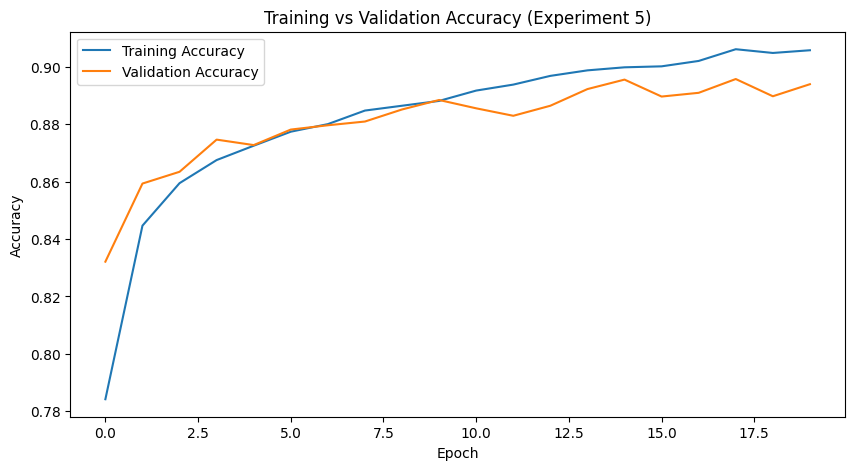

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_experiment5.history['accuracy'], label='Training Accuracy')
plt.plot(history_experiment5.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy (Experiment 5)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Loss Curves

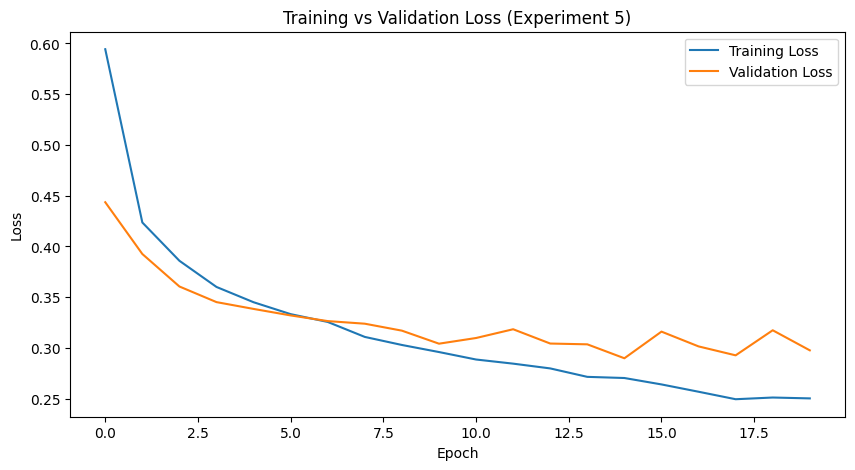

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_experiment5.history['loss'], label='Training Loss')
plt.plot(history_experiment5.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss (Experiment 5)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Interpretation of Training Curves

The training curves provide insight into how the model learned during optimisation.

First, the training accuracy increases steadily during the early epochs while the loss decreases, indicating that the model is successfully learning meaningful patterns from the training data. The learning process appears stable, with no sudden fluctuations in the curves, suggesting that the optimisation process is well behaved.

The validation accuracy initially improves alongside the training accuracy but begins to plateau after several epochs. This behaviour indicates that the model has learned most of the generalisable structure in the dataset and that further training provides diminishing improvements.

Comparing the training and validation curves also provides evidence about overfitting. The training accuracy continues to improve slightly in later epochs, while the validation accuracy stabilises. This small gap suggests mild overfitting, which is expected in neural networks but appears to be reasonably controlled, particularly due to the use of dropout regularisation in later experiments.

Finally, the curves suggest that training for around 20 epochs is broadly appropriate. The model converges before the final epochs, and additional training would likely produce only marginal improvements while potentially increasing overfitting.

Overall, the learning curves indicate stable convergence and reasonable generalisation performance.

# Confusion Matrix

To further evaluate the classification performance of the best-performing model, a confusion matrix is generated. This visualisation shows how frequently each class is correctly or incorrectly classified.

### Code Reference

The confusion matrix implementation uses standard functions from the scikit-learn library, which are commonly used for evaluating classification models in machine learning workflows.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


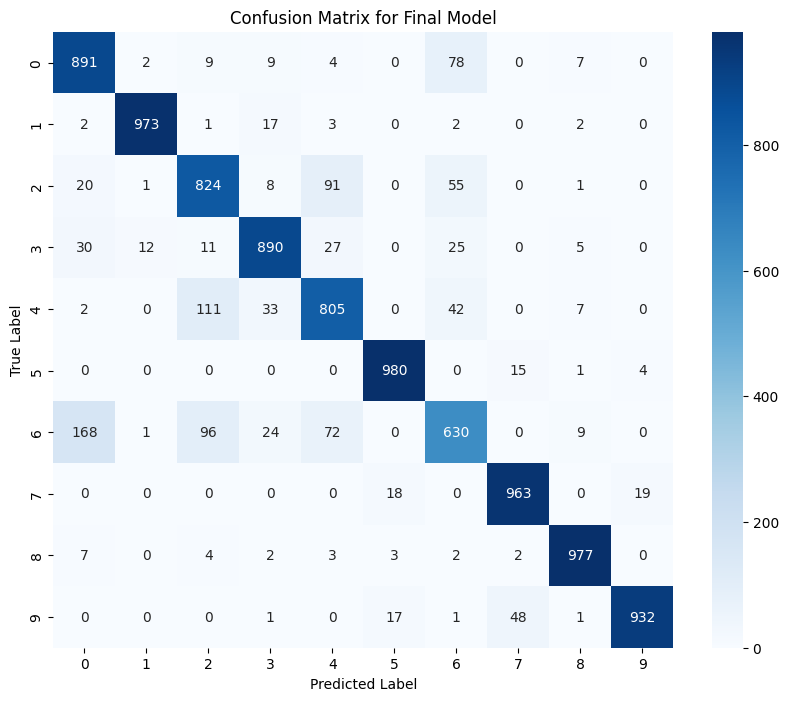

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

predictions = experiment5_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Final Model")

plt.show()

The confusion matrix illustrates the performance of the model across the ten Fashion-MNIST classes. Most classes are predicted correctly, particularly visually distinct categories such as bags and shoes. Some confusion occurs between visually similar clothing items such as shirts, coats, and pullovers, which share similar shapes in grayscale images. This indicates that while the model performs well overall, distinguishing between certain clothing categories remains challenging.

A closer inspection of the confusion matrix suggests that most errors occur between clothing categories with similar visual characteristics. For example, shirts, pullovers, and coats often share similar silhouettes and textures in the low-resolution grayscale images used in the dataset. Because the model relies on fully connected dense layers rather than convolutional layers, it does not explicitly capture spatial patterns such as edges, textures, or local shapes within the images.

As a result, the network may struggle to distinguish between categories that differ only by subtle structural features. In contrast, categories such as bags or footwear are generally easier to classify because their shapes differ more strongly from other classes. These observations highlight a limitation of dense neural networks when applied directly to image classification tasks, where convolutional architectures are typically more effective at capturing spatial structure.

After examining prediction behaviour through the confusion matrix, it is also useful to present the structure of the selected model visually. This helps connect the performance results back to the underlying architecture used in the investigation.

# Model Architecture

The final model architecture used in this study consists of three fully connected hidden layers with ReLU activation functions and dropout regularisation. The network receives flattened 28×28 pixel images as input and produces probability predictions for the ten Fashion-MNIST clothing categories using a softmax output layer.

The architecture of the final model is visualised below.

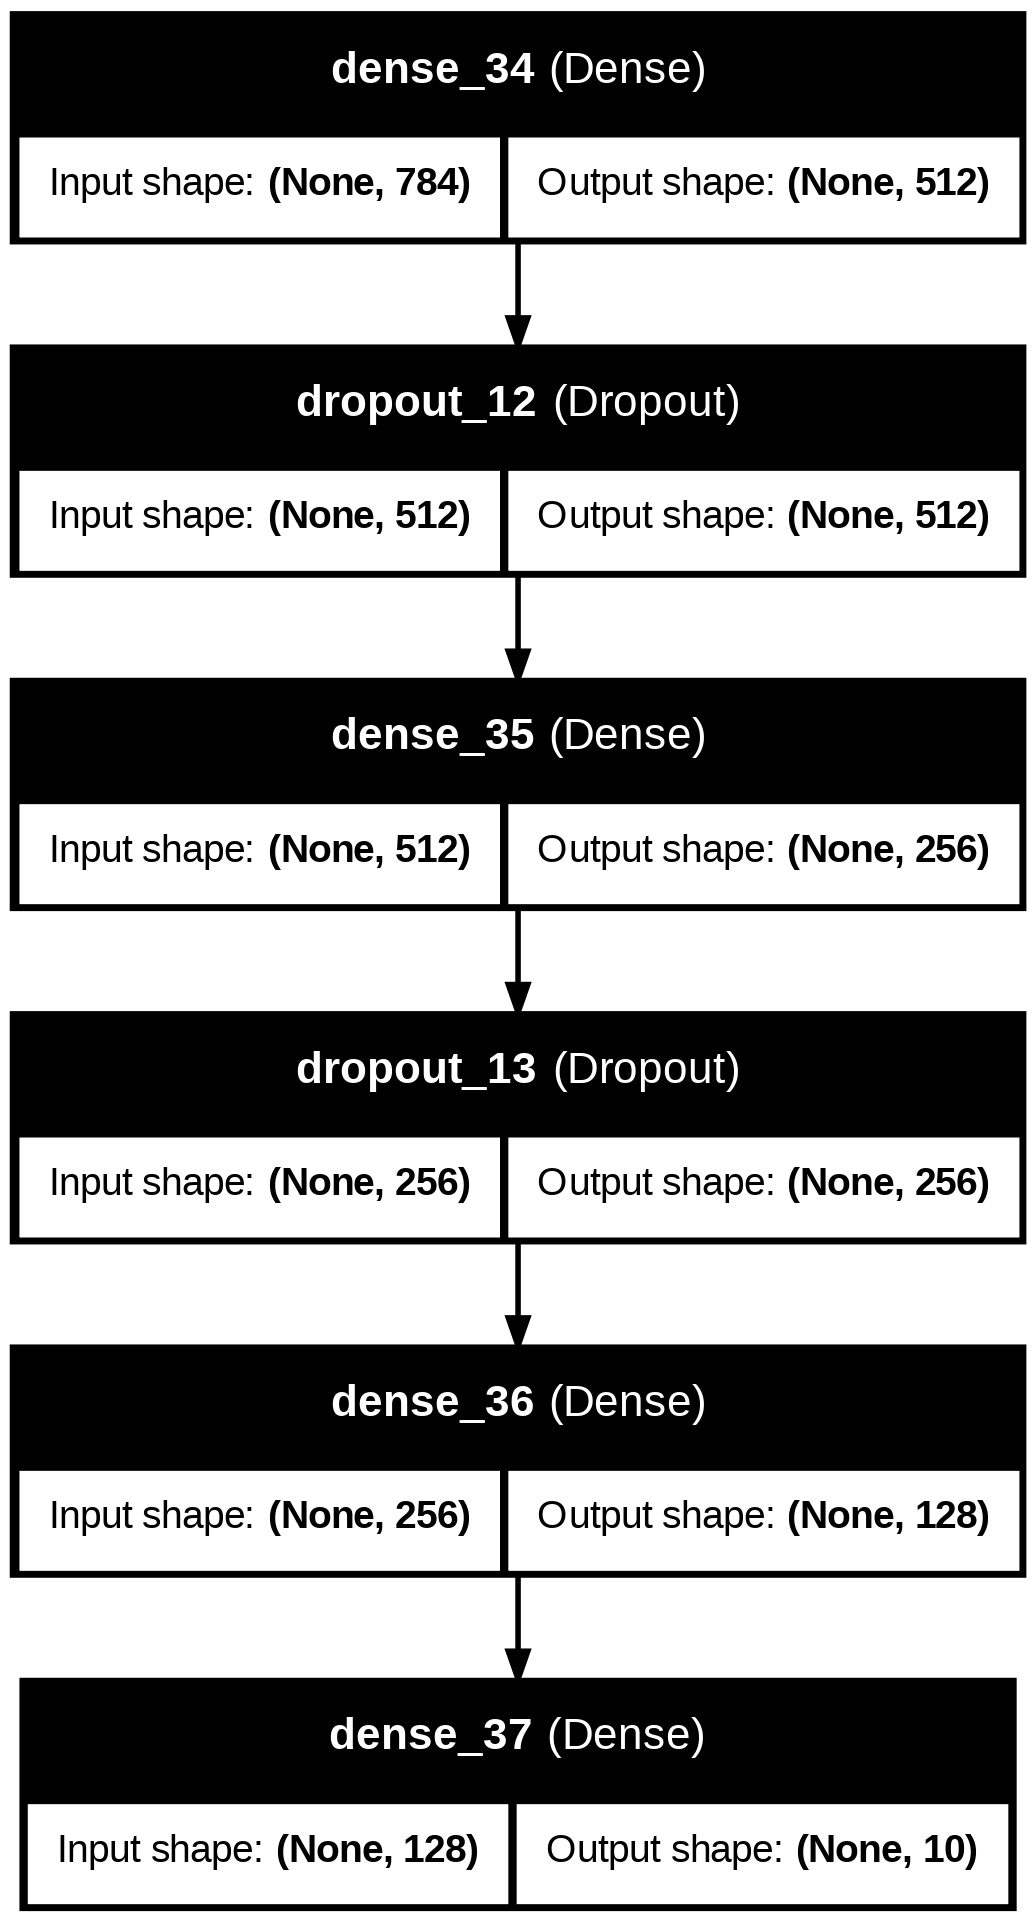

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    experiment5_model,
    show_shapes=True,
    show_layer_names=True
)

The previous sections have presented the experimental results, learning behaviour, class-level errors, and model structure. The discussion section now brings these findings together in order to interpret the overall patterns observed across the investigation.

# 12. Discussion

This study investigated the effect of network architecture, regularisation and training parameters on the performance of neural networks for Fashion-MNIST classification.

Increasing the hidden layer size slightly improved performance, indicating that additional model capacity can help capture useful patterns in the data. Introducing deeper network architectures provided limited improvements, suggesting that the dataset does not require highly complex models. The larger network architecture increased the model capacity to over 567,000 trainable parameters, allowing the network to learn more complex feature representations from the dataset.

Regularisation experiments demonstrated that dropout can reduce overfitting, but excessive dropout significantly reduces training performance. A moderate dropout rate of 0.3 provided the best balance between generalisation and learning capacity.

The largest network architecture combined with moderate dropout achieved the best overall performance, reaching a test accuracy of approximately 89.17%. This suggests that increasing model capacity while applying appropriate regularisation can lead to improved classification performance.

Batch size experiments showed that reducing the batch size had only a minor effect on the final results, indicating that architectural choices and regularisation strategies are more influential factors in this task.

# 13. Conclusion

This project applied a systematic deep learning workflow to the Fashion-MNIST dataset using neural networks constructed with dense and dropout layers. Multiple experiments were conducted to investigate the impact of model capacity, network depth, regularisation and training parameters.

The results demonstrated that moderate regularisation combined with increased model capacity provided the best classification performance. The final model achieved a test accuracy of approximately 89%, demonstrating that relatively simple neural network architectures can perform effectively on this dataset.

Overall, the experiments highlight the importance of carefully balancing model complexity and regularisation in order to achieve optimal performance in deep learning models.

A key overall finding from this investigation is that model capacity combined with moderate regularisation had the greatest impact on performance. Increasing network width alone provided only modest improvements, while excessive regularisation reduced learning capacity. The results also highlight an important limitation of dense neural networks for image data: because fully connected layers do not explicitly exploit spatial structure in images, the model struggles to distinguish between visually similar classes. A further limitation of this investigation is that the architecture was restricted to dense and dropout layers, meaning that more specialised image-processing architectures such as convolutional neural networks could not be explored.